### Train Swin Transformer + ArcFace Embedding

Thay FC head, xuất embedding vector 128-d.
Phân loại bằng cosine similarity với prototype database

**Output**:
- `models/swin_embedding.pth` — backbone + projection head
- `models/prototypes.npz` — ArcFace weights làm prototype vectors

In [1]:
# ============================================================
# CELL 1 — Cài đặt: Mount Drive, cài thư viện, kiểm tra GPU
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

%pip install transformers timm torch torchvision scikit-learn tqdm -q

import torch
from pathlib import Path

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU      : {gpu}")
    print(f"VRAM     : {vram:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = Path('/content/drive/MyDrive/DATN')
assert BASE_DIR.exists(), f'Sai đường dẫn: {BASE_DIR}'
print(f"\nBASE_DIR = {BASE_DIR}")
print(f"DEVICE   = {DEVICE}")

!nvidia-smi

Mounted at /content/drive
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA L4
VRAM     : 23.7 GB

BASE_DIR = /content/drive/MyDrive/DATN
DEVICE   = cuda
Mon Apr 20 17:26:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   37C    P8             13W /   72W |       3MiB /  23034MiB |  

In [2]:
# ============================================================
# CELL 2 — Import thư viện & Cấu hình (cố định cho Colab T4)
# ============================================================
import os
import random
import time
import math
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from transformers import SwinModel
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

BATCH_SIZE    = 32
NUM_WORKERS   = 2
MODELS_DIR    = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

MODEL_CKPT    = 'microsoft/swin-small-patch4-window7-224'
EMBED_DIM     = 128       # Bottleneck 768→128
IMG_SIZE      = 224
DROPOUT       = 0.3

# Lịch trình huấn luyện
NUM_EPOCHS    = 50
LR            = 5e-6
LR_HEAD       = 5e-4
MIN_LR        = 1e-7
WARMUP_EPOCHS = 5
FREEZE_EPOCHS = 3
PATIENCE      = 12

# ArcFace
ARCFACE_SCALE  = 30.0
ARCFACE_MARGIN = 0.3

print(f'Mô hình       : {MODEL_CKPT}')
print(f'Chiều embedding: {EMBED_DIM} (nén từ 768)')
print(f'Batch size     : {BATCH_SIZE}')
print(f'ArcFace        : s={ARCFACE_SCALE}, m={ARCFACE_MARGIN}')
print(f'Epochs         : {NUM_EPOCHS} (khởi động={WARMUP_EPOCHS}, đóng băng={FREEZE_EPOCHS})')
print(f'Early stopping : patience={PATIENCE}')
print(f'LR backbone    : {LR} | LR head: {LR_HEAD}')
print(f'Dropout        : {DROPOUT}')

Mô hình       : microsoft/swin-small-patch4-window7-224
Chiều embedding: 128 (nén từ 768)
Batch size     : 32
ArcFace        : s=30.0, m=0.3
Epochs         : 50 (khởi động=5, đóng băng=3)
Early stopping : patience=12
LR backbone    : 5e-06 | LR head: 0.0005
Dropout        : 0.3


In [3]:
# ============================================================
# CELL 3 — Tải dữ liệu & Tăng cường ảnh
# ============================================================
import json
import shutil
import subprocess

LOCAL_CLF_DIR = Path('/content/clf_data')
KAGGLE_DATASET = 'abdallahalidev/plantvillage-dataset'
IMG_EXTS = ('*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG')

# ── Kaggle credentials ──
KAGGLE_JSON = Path('/root/.kaggle/kaggle.json')
Path('/root/.kaggle').mkdir(exist_ok=True)

kaggle_creds = BASE_DIR / 'data' / 'kaggle.json'
if kaggle_creds.exists():
    shutil.copy2(str(kaggle_creds), str(KAGGLE_JSON))
    KAGGLE_JSON.chmod(0o600)
    print('Kaggle credentials: từ Drive')
elif not KAGGLE_JSON.exists():
    KAGGLE_USERNAME = 'seotoww'
    KAGGLE_KEY = '7906ccbc30f5ece58ddca958219a9ecb'
    KAGGLE_JSON.write_text(json.dumps({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}))
    KAGGLE_JSON.chmod(0o600)
    print('Kaggle credentials: hardcoded')
else:
    print('Kaggle credentials: đã có')


def count_images(folder):
    return sum(1 for ext in IMG_EXTS for _ in folder.rglob(ext))


def list_images(folder):
    imgs = []
    for ext in IMG_EXTS:
        imgs.extend(folder.glob(ext))
    return list({p.name.lower(): p for p in imgs}.values())


SPLIT_RATIOS = (0.80, 0.10, 0.10)
SPLITS = ('train', 'valid', 'test')

splits_ready = all(
    (LOCAL_CLF_DIR / sp).exists() and count_images(LOCAL_CLF_DIR / sp) > 100
    for sp in SPLITS
)

if splits_ready:
    n_classes = len([d for d in (LOCAL_CLF_DIR / 'train').iterdir() if d.is_dir()])
    print(f'Dữ liệu đã có trên local ({n_classes} classes) — bỏ qua tải lại')
else:
    # Tải từ Kaggle
    download_dir = Path('/content/plantvillage_raw')
    download_dir.mkdir(parents=True, exist_ok=True)

    zip_files = list(download_dir.glob('*.zip'))
    if not zip_files:
        print(f'Tải PlantVillage từ Kaggle ({KAGGLE_DATASET})...')
        result = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', KAGGLE_DATASET, '-p', str(download_dir)],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            raise RuntimeError(f'Kaggle download thất bại:\n{result.stderr}')
        zip_files = list(download_dir.glob('*.zip'))

    # Giải nén
    import zipfile
    zip_path = zip_files[0]
    print(f'Giải nén {zip_path.name} ({zip_path.stat().st_size / 1e9:.2f} GB)...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        members = [m for m in zf.infolist() if not m.is_dir()]
        pending = [m for m in members if not (download_dir / m.filename).exists()]
        if pending:
            for member in pending:
                zf.extract(member, download_dir)
            print(f'Giải nén {len(pending)} files')
        else:
            print('Đã giải nén đầy đủ')

    color_dirs = sorted(download_dir.rglob('color'), key=lambda p: len(list(p.iterdir())))
    if color_dirs:
        source_dir = color_dirs[-1]
    else:
        all_subdirs = [d for d in download_dir.rglob('*') if d.is_dir()
                       and sum(1 for _ in d.iterdir()) > 10]
        source_dir = max(all_subdirs, key=lambda d: sum(1 for _ in d.iterdir()))

    class_dirs = sorted([d for d in source_dir.iterdir() if d.is_dir()])
    print(f'Source: {source_dir} — {len(class_dirs)} classes')

    import random as _rnd
    _rnd.seed(SEED)

    if LOCAL_CLF_DIR.exists():
        shutil.rmtree(LOCAL_CLF_DIR)

    for cls_dir in class_dirs:
        imgs = list_images(cls_dir)
        _rnd.shuffle(imgs)

        n = len(imgs)
        n_train = int(n * SPLIT_RATIOS[0])
        n_valid = int(n * SPLIT_RATIOS[1])
        splits_imgs = {
            'train': imgs[:n_train],
            'valid': imgs[n_train:n_train + n_valid],
            'test':  imgs[n_train + n_valid:],
        }
        for sp, sp_imgs in splits_imgs.items():
            dst = LOCAL_CLF_DIR / sp / cls_dir.name
            dst.mkdir(parents=True, exist_ok=True)
            for src in sp_imgs:
                shutil.copy2(src, dst / src.name)

    for sp in SPLITS:
        n = count_images(LOCAL_CLF_DIR / sp)
        nc = len([d for d in (LOCAL_CLF_DIR / sp).iterdir() if d.is_dir()])
        print(f'  {sp}: {nc} classes, {n:,} ảnh')

for sp in SPLITS:
    sp_dir = LOCAL_CLF_DIR / sp
    if not sp_dir.exists():
        continue
    for cls_dir in sp_dir.iterdir():
        if cls_dir.is_dir():
            if not list_images(cls_dir):
                shutil.rmtree(cls_dir)

# Tăng cường ảnh — RandAugment + RandomErasing chống overfitting
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Tạo ImageFolder
train_ds = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'valid'), transform=eval_transform)
test_ds  = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'test'),  transform=eval_transform)

# ── Kiểm tra & đồng bộ class mapping giữa các tập ──
def remap_dataset(dataset, ref_class_to_idx, split_name):
    """Đảm bảo dataset dùng cùng class mapping với tập train."""
    if dataset.class_to_idx == ref_class_to_idx:
        print(f'  ✓ {split_name}: class mapping đồng nhất với train')
        return

    remap = {}
    for cls_name, old_idx in dataset.class_to_idx.items():
        if cls_name in ref_class_to_idx:
            remap[old_idx] = ref_class_to_idx[cls_name]
        else:
            print(f'  ⚠️ {split_name}: class "{cls_name}" không có trong train — bỏ qua')

    new_samples = [(p, remap[lbl]) for p, lbl in dataset.samples if lbl in remap]
    removed = len(dataset.samples) - len(new_samples)
    dataset.samples = new_samples
    dataset.targets = [s[1] for s in new_samples]
    dataset.imgs = new_samples
    dataset.class_to_idx = ref_class_to_idx
    dataset.classes = [k for k, v in sorted(ref_class_to_idx.items(), key=lambda x: x[1])]

    if removed:
        print(f'  ⚠️ {split_name}: đã loại {removed} ảnh thuộc class không có trong train')
    print(f'   {split_name}: đã remap labels → {len(new_samples)} ảnh')

print('Kiểm tra class mapping:')
remap_dataset(val_ds,  train_ds.class_to_idx, 'Val')
remap_dataset(test_ds, train_ds.class_to_idx, 'Test')

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nSố class  : {NUM_CLASSES}')
print(f'Train     : {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')

# WeightedRandomSampler — cân bằng class
label_list   = [label for _, label in train_ds.imgs]
class_counts = Counter(label_list)
inv_freq     = {cls: 1.0 / count for cls, count in class_counts.items()}
sampler      = WeightedRandomSampler(
    weights=[inv_freq[label] for label in label_list],
    num_samples=len(label_list),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f'DataLoader sẵn sàng — batch={BATCH_SIZE}, workers={NUM_WORKERS}')

Kaggle credentials: hardcoded
Tải PlantVillage từ Kaggle (abdallahalidev/plantvillage-dataset)...
Giải nén plantvillage-dataset.zip (2.19 GB)...
Giải nén 162916 files
Source: /content/plantvillage_raw/plantvillage dataset/color — 38 classes
  train: 38 classes, 43,429 ảnh
  valid: 38 classes, 5,417 ảnh
  test: 38 classes, 5,459 ảnh
Kiểm tra class mapping:
  ✓ Val: class mapping đồng nhất với train
  ✓ Test: class mapping đồng nhất với train

Số class  : 38
Train     : 43,429 | Val: 5,417 | Test: 5,459
DataLoader sẵn sàng — batch=32, workers=2


In [4]:
# ============================================================
# CELL 4 — Mô hình: Swin backbone + ArcFace head
# ============================================================


class ArcFaceHead(nn.Module):
    """ArcFace angular margin loss head.

    Huấn luyện: cos(θ + m) × s cho class đúng, cos(θ) × s cho class khác.
    Đánh giá  : cos(θ) × s (không margin) để đo chính xác.
    """

    def __init__(self, embed_dim, num_classes, scale=30.0, margin=0.3):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.threshold = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels=None):
        normed_emb = F.normalize(embeddings, p=2, dim=1)
        normed_w   = F.normalize(self.weight, p=2, dim=1)
        cosine     = F.linear(normed_emb, normed_w)

        # Khi đánh giá: không áp margin
        if labels is None:
            return cosine * self.scale

        sine = torch.sqrt(1.0 - torch.clamp(cosine ** 2, max=1.0))
        phi  = cosine * self.cos_m - sine * self.sin_m
        phi  = torch.where(cosine > self.threshold, phi, cosine - self.mm)

        one_hot = F.one_hot(labels, num_classes=normed_w.size(0)).float()
        logits  = one_hot * phi + (1.0 - one_hot) * cosine
        return logits * self.scale


class SwinEmbedding(nn.Module):
    """Swin backbone → pooled → dropout → projection → L2-normalized embedding."""

    def __init__(self, model_ckpt, embed_dim=128, dropout=0.3):
        super().__init__()
        self.backbone = SwinModel.from_pretrained(model_ckpt)
        backbone_dim = self.backbone.config.hidden_size
        self.projection = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        pooled  = outputs.pooler_output
        emb     = self.projection(pooled)
        return F.normalize(emb, p=2, dim=1)


# Khởi tạo mô hình
embed_model = SwinEmbedding(MODEL_CKPT, embed_dim=EMBED_DIM, dropout=DROPOUT).to(DEVICE)

prev_ckpt_path = MODELS_DIR / 'swin_classifier.pth'
if prev_ckpt_path.exists():
    prev_ckpt = torch.load(str(prev_ckpt_path), map_location=DEVICE, weights_only=False)
    backbone_state = {}
    for k, v in prev_ckpt['model_state'].items():
        if k.startswith('swin.'):
            backbone_state[k[len('swin.'):]] = v
    loaded_keys = embed_model.backbone.load_state_dict(backbone_state, strict=False)
    print(f'Đã tải backbone từ NB03: {len(backbone_state)} keys')
    if loaded_keys.missing_keys:
        print(f'  Thiếu: {loaded_keys.missing_keys[:5]}')
else:
    print('Không có checkpoint NB03 — dùng weights HuggingFace pretrained')

arcface_head = ArcFaceHead(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    scale=ARCFACE_SCALE,
    margin=ARCFACE_MARGIN,
).to(DEVICE)

total_params = sum(p.numel() for p in embed_model.parameters()) + \
               sum(p.numel() for p in arcface_head.parameters())
print(f'\nTổng tham số : {total_params:,}')
print(f'Backbone     : {sum(p.numel() for p in embed_model.backbone.parameters()):,}')
print(f'Projection   : {sum(p.numel() for p in embed_model.projection.parameters()):,}')
print(f'ArcFace head : {sum(p.numel() for p in arcface_head.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

Đã tải backbone từ NB03: 447 keys

Tổng tham số : 48,940,810
Backbone     : 48,837,258
Projection   : 98,688
ArcFace head : 4,864


In [5]:
# ============================================================
# CELL 5 — Vòng lặp huấn luyện
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def freeze_backbone(model, freeze=True):
    for p in model.backbone.parameters():
        p.requires_grad = not freeze
    print(f'  Backbone {"ĐÃ ĐÓNG BĂNG" if freeze else "ĐÃ MỞ BĂNG"}')


freeze_backbone(embed_model, freeze=True)

optimizer = AdamW([
    {'params': embed_model.backbone.parameters(),    'lr': LR,      'name': 'backbone'},
    {'params': embed_model.projection.parameters(),  'lr': LR_HEAD, 'name': 'projection'},
    {'params': arcface_head.parameters(),            'lr': LR_HEAD, 'name': 'arcface'},
], weight_decay=0.05)

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=MIN_LR)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                            milestones=[WARMUP_EPOCHS])

USE_AMP = DEVICE.type == 'cuda'
scaler  = torch.amp.GradScaler('cuda', enabled=USE_AMP)

history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
no_improve   = 0
best_ckpt    = MODELS_DIR / 'swin_embedding_best.pth'
last_ckpt    = MODELS_DIR / 'swin_embedding_last.pth'
start_epoch  = 1

if last_ckpt.exists():
    ckpt_r = torch.load(str(last_ckpt), map_location=DEVICE, weights_only=False)
    if ckpt_r.get('num_labels', -1) == NUM_CLASSES and ckpt_r.get('embed_dim', -1) == EMBED_DIM:
        resume = input('Tiếp tục huấn luyện? [y/N]: ').strip().lower()
        if resume == 'y':
            embed_model.load_state_dict(ckpt_r['embed_model_state'])
            arcface_head.load_state_dict(ckpt_r['arcface_state'])
            try:
                optimizer.load_state_dict(ckpt_r['optimizer'])
                scheduler.load_state_dict(ckpt_r['scheduler'])
            except Exception as e:
                print(f'Bỏ qua khôi phục optimizer/scheduler: {e}')
            if 'scaler' in ckpt_r:
                scaler.load_state_dict(ckpt_r['scaler'])
            history      = ckpt_r['history']
            best_val_acc = ckpt_r['best_val_acc']
            start_epoch  = ckpt_r['epoch'] + 1
            if start_epoch > FREEZE_EPOCHS:
                freeze_backbone(embed_model, freeze=False)
            print(f'Tiếp tục từ epoch {ckpt_r["epoch"]} | best_val_acc={best_val_acc:.4f}')
    else:
        print('Checkpoint không khớp (số class hoặc embed_dim) — huấn luyện lại từ đầu')


def run_epoch(loader, is_train=True, desc=''):
    if is_train:
        embed_model.train()
        arcface_head.train()
    else:
        embed_model.eval()
        arcface_head.eval()

    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(loader, desc=desc, leave=False, bar_format='{l_bar}{bar:20}{r_bar}', ncols=90)

    with ctx:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast('cuda', enabled=USE_AMP):
                embeddings = embed_model(pixel_values=imgs)
                if is_train:
                    logits = arcface_head(embeddings, labels)
                else:
                    logits = arcface_head(embeddings)  # không margin khi đánh giá
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    list(embed_model.parameters()) + list(arcface_head.parameters()),
                    max_norm=1.0,
                )
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.3f}')

    return total_loss / total, correct / total


print(f'\nHuấn luyện epoch {start_epoch}→{NUM_EPOCHS} (patience={PATIENCE})')
print(f'Đóng băng backbone {FREEZE_EPOCHS} epoch đầu')
print('─' * 85)

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        freeze_backbone(embed_model, freeze=False)
        no_improve = 0
        print('  → Reset bộ đếm early stopping')

    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, is_train=True,  desc=f'Ep{epoch:02d} Train')
    va_loss, va_acc = run_epoch(val_loader,   is_train=False, desc=f'Ep{epoch:02d} Val')
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]

    improved = va_acc > best_val_acc
    if improved:
        best_val_acc = va_acc
        no_improve   = 0
        torch.save({
            'epoch'             : epoch,
            'embed_model_state' : embed_model.state_dict(),
            'arcface_state'     : arcface_head.state_dict(),
            'val_acc'           : va_acc,
            'class_names'       : CLASS_NAMES,
            'num_labels'        : NUM_CLASSES,
            'embed_dim'         : EMBED_DIM,
            'swin_config'       : dict(embed_model.backbone.config.to_dict()),
        }, str(best_ckpt))
    else:
        no_improve += 1

    if epoch <= FREEZE_EPOCHS:
        phase = 'đóng băng'
    elif epoch <= WARMUP_EPOCHS:
        phase = 'khởi động'
    else:
        phase = 'cosine'

    marker = ' ★' if improved else f' ({no_improve}/{PATIENCE})'
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} [{phase}] │ '
          f'train loss={tr_loss:.4f} acc={tr_acc:.3f} │ '
          f'val loss={va_loss:.4f} acc={va_acc:.3f} │ '
          f'lr={lr_now:.1e} │ {elapsed:.0f}s{marker}')

    torch.save({
        'epoch'             : epoch,
        'embed_model_state' : embed_model.state_dict(),
        'arcface_state'     : arcface_head.state_dict(),
        'optimizer'         : optimizer.state_dict(),
        'scheduler'         : scheduler.state_dict(),
        'scaler'            : scaler.state_dict(),
        'history'           : history,
        'best_val_acc'      : best_val_acc,
        'class_names'       : CLASS_NAMES,
        'num_labels'        : NUM_CLASSES,
        'embed_dim'         : EMBED_DIM,
        'swin_config'       : dict(embed_model.backbone.config.to_dict()),
    }, str(last_ckpt))

    # Early stopping — chỉ đếm SAU KHI mở băng backbone
    if epoch > FREEZE_EPOCHS and no_improve >= PATIENCE:
        print(f'\n⛔ Dừng sớm tại epoch {epoch} — không cải thiện sau {PATIENCE} epoch')
        break

print('─' * 85)
print(f'Hoàn tất huấn luyện. Val accuracy tốt nhất = {best_val_acc * 100:.2f}%')

  Backbone ĐÃ ĐÓNG BĂNG
Checkpoint không khớp (số class hoặc embed_dim) — huấn luyện lại từ đầu

Huấn luyện epoch 1→50 (patience=12)
Đóng băng backbone 3 epoch đầu
─────────────────────────────────────────────────────────────────────────────────────


Ep01 Train:   0%|                    | 0/1358 [00:00<?, ?it/s]

Ep01 Val:   0%|                    | 0/170 [00:00<?, ?it/s]

Epoch 01/50 [đóng băng] │ train loss=1.7283 acc=0.877 │ val loss=1.6997 acc=1.000 │ lr=1.4e-06 │ 104s ★


Ep02 Train:   0%|                    | 0/1358 [00:00<?, ?it/s]

...

Ep14 Val:   0%|                    | 0/170 [00:00<?, ?it/s]

Epoch 14/50 [cosine] │ train loss=0.7174 acc=0.997 │ val loss=1.4358 acc=1.000 │ lr=4.5e-06 │ 265s (11/12)


Ep15 Train:   0%|                    | 0/1358 [00:00<?, ?it/s]

Ep15 Val:   0%|                    | 0/170 [00:00<?, ?it/s]

Epoch 15/50 [cosine] │ train loss=0.7167 acc=0.997 │ val loss=1.4331 acc=1.000 │ lr=4.4e-06 │ 265s (12/12)

⛔ Dừng sớm tại epoch 15 — không cải thiện sau 12 epoch
─────────────────────────────────────────────────────────────────────────────────────
Hoàn tất huấn luyện. Val accuracy tốt nhất = 99.96%


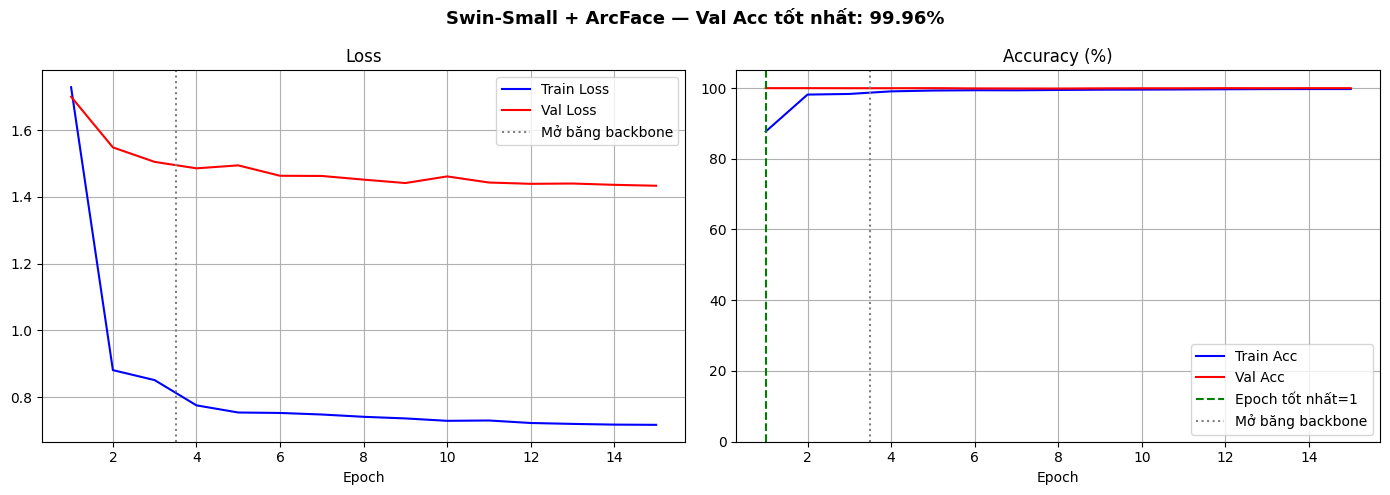

In [6]:
# ============================================================
# CELL 6 — Biểu đồ quá trình huấn luyện
# ============================================================
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'r-', label='Val Loss')
ax1.axvline(FREEZE_EPOCHS + 0.5, color='gray', linestyle=':', label='Mở băng backbone')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, [x * 100 for x in history['train_acc']], 'b-', label='Train Acc')
ax2.plot(epochs_range, [x * 100 for x in history['val_acc']],   'r-', label='Val Acc')
best_ep = np.argmax(history['val_acc']) + 1
ax2.axvline(best_ep, color='g', linestyle='--', label=f'Epoch tốt nhất={best_ep}')
ax2.axvline(FREEZE_EPOCHS + 0.5, color='gray', linestyle=':', label='Mở băng backbone')
ax2.set_title('Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)
ax2.set_ylim(0, 105)

plt.suptitle(f'Swin-Small + ArcFace — Val Acc tốt nhất: {best_val_acc * 100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'swin_arcface_curves.png'), dpi=150)
plt.show()

In [7]:
# ============================================================
# CELL 7 — Xây dựng Prototype Database
# ============================================================

# Tải checkpoint tốt nhất
ckpt = torch.load(str(best_ckpt), map_location=DEVICE, weights_only=False)
embed_model.load_state_dict(ckpt['embed_model_state'])
arcface_head.load_state_dict(ckpt['arcface_state'])
embed_model.eval()
arcface_head.eval()
print(f'Đã tải checkpoint tốt nhất (epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.4f})')

# ── Phương pháp 1: ArcFace weights = class centers tối ưu ──
# ArcFace training học weights W[i] sao cho cos(embedding, W[i]) cực đại cho class i
# → W[i] chính là prototype tối ưu cho class i
arcface_prototypes = F.normalize(arcface_head.weight, p=2, dim=1).detach().cpu().numpy()
print(f'\nArcFace prototypes: {arcface_prototypes.shape}')

# ── Phương pháp 2: Trung bình embedding từ tập train (để so sánh) ──
all_embeddings = []
all_labels     = []

proto_ds     = datasets.ImageFolder(str(LOCAL_CLF_DIR / 'train'), transform=eval_transform)
proto_ds.class_to_idx = train_ds.class_to_idx
proto_ds.classes      = train_ds.classes
proto_loader = DataLoader(proto_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

with torch.no_grad():
    for imgs, labels in tqdm(proto_loader, desc='Tính embedding toàn bộ train'):
        imgs = imgs.to(DEVICE)
        embs = embed_model(pixel_values=imgs).cpu().numpy()
        all_embeddings.append(embs)
        all_labels.extend(labels.tolist())

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels     = np.array(all_labels)
print(f'Tổng embedding: {all_embeddings.shape}')

mean_prototypes = np.zeros((NUM_CLASSES, EMBED_DIM), dtype=np.float32)
for i in range(NUM_CLASSES):
    mask = all_labels == i
    mean_emb = all_embeddings[mask].mean(axis=0)
    mean_prototypes[i] = mean_emb / (np.linalg.norm(mean_emb) + 1e-8)

# So sánh 2 phương pháp
print(f'\nSo sánh ArcFace weights vs Trung bình embedding (cosine similarity):')
for i in range(NUM_CLASSES):
    sim = np.dot(arcface_prototypes[i], mean_prototypes[i])
    count = (all_labels == i).sum()
    print(f'  {CLASS_NAMES[i]}: sim={sim:.4f} ({count} mẫu)')

# ── Lưu prototype ──
# Dùng ArcFace weights cho class có sẵn (tối ưu qua training)
# Khi user thêm class mới → backend tính mean embedding → thêm prototype
proto_path = MODELS_DIR / 'prototypes.npz'
np.savez(
    str(proto_path),
    prototypes=arcface_prototypes,
    class_names=np.array(CLASS_NAMES),
)
print(f'\nĐã lưu prototypes: {proto_path}')
print(f'Kích thước: {arcface_prototypes.shape}')

Đã tải checkpoint tốt nhất (epoch 1, val_acc=0.9996)

ArcFace prototypes: (38, 128)


Tính embedding toàn bộ train:   0%|          | 0/1358 [00:00<?, ?it/s]

Tổng embedding: (43429, 128)

So sánh ArcFace weights vs Trung bình embedding (cosine similarity):
  Apple___Apple_scab: sim=0.5623 (504 mẫu)
  Apple___Black_rot: sim=0.5507 (496 mẫu)
  Apple___Cedar_apple_rust: sim=0.5501 (220 mẫu)
  Apple___healthy: sim=0.5687 (1316 mẫu)
  Blueberry___healthy: sim=0.5588 (1201 mẫu)
  Cherry_(including_sour)___Powdery_mildew: sim=0.5433 (841 mẫu)
  Cherry_(including_sour)___healthy: sim=0.5636 (683 mẫu)
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: sim=0.5693 (410 mẫu)
  Corn_(maize)___Common_rust_: sim=0.5234 (953 mẫu)
  Corn_(maize)___Northern_Leaf_Blight: sim=0.5695 (788 mẫu)
  Corn_(maize)___healthy: sim=0.5378 (929 mẫu)
  Grape___Black_rot: sim=0.5722 (944 mẫu)
  Grape___Esca_(Black_Measles): sim=0.5375 (1106 mẫu)
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): sim=0.5362 (860 mẫu)
  Grape___healthy: sim=0.5756 (338 mẫu)
  Orange___Haunglongbing_(Citrus_greening): sim=0.5738 (4405 mẫu)
  Peach___Bacterial_spot: sim=0.5683 (1837 mẫu)
  Peach

In [8]:
# ============================================================
# CELL 8 — Đánh giá: So sánh 2 phương pháp prototype trên tập Test
# ============================================================
from sklearn.metrics import classification_report


def classify_by_cosine(embeddings, prototypes):
    """Phân loại bằng cosine similarity với prototype."""
    similarity = embeddings @ prototypes.T
    predictions = similarity.argmax(axis=1)
    return predictions, similarity


# Tính embedding cho tập test
test_embeddings = []
test_labels     = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Tính embedding test'):
        imgs = imgs.to(DEVICE)
        embs = embed_model(pixel_values=imgs).cpu().numpy()
        test_embeddings.append(embs)
        test_labels.extend(labels.tolist())

test_embeddings = np.concatenate(test_embeddings, axis=0)
test_labels     = np.array(test_labels)

# ── So sánh 2 phương pháp prototype ──
print('=' * 65)
test_acc = 0.0
for name, protos in [('ArcFace weights (tối ưu)', arcface_prototypes),
                     ('Trung bình embedding',     mean_prototypes)]:
    preds, _ = classify_by_cosine(test_embeddings, protos)
    acc = (preds == test_labels).mean()
    print(f'{name}: Test Accuracy = {acc * 100:.2f}%')
    if 'ArcFace' in name:
        test_acc = acc
        predictions = preds
print('=' * 65)

print(f'\nBáo cáo phân loại chi tiết (ArcFace prototypes):')
print(classification_report(
    test_labels, predictions,
    target_names=CLASS_NAMES,
    labels=list(range(NUM_CLASSES)),
    digits=3,
    zero_division=0,
))

Tính embedding test:   0%|          | 0/171 [00:00<?, ?it/s]

ArcFace weights (tối ưu): Test Accuracy = 99.98%
Trung bình embedding: Test Accuracy = 99.98%

Báo cáo phân loại chi tiết (ArcFace prototypes):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      1.000     1.000     1.000        63
                                 Apple___Black_rot      1.000     1.000     1.000        63
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        28
                                   Apple___healthy      1.000     1.000     1.000       165
                               Blueberry___healthy      1.000     1.000     1.000       151
          Cherry_(including_sour)___Powdery_mildew      1.000     1.000     1.000       106
                 Cherry_(including_sour)___healthy      1.000     1.000     1.000        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      1.000     1.000     1.000        52
                       Corn

Đang chạy t-SNE trên 3000 mẫu...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


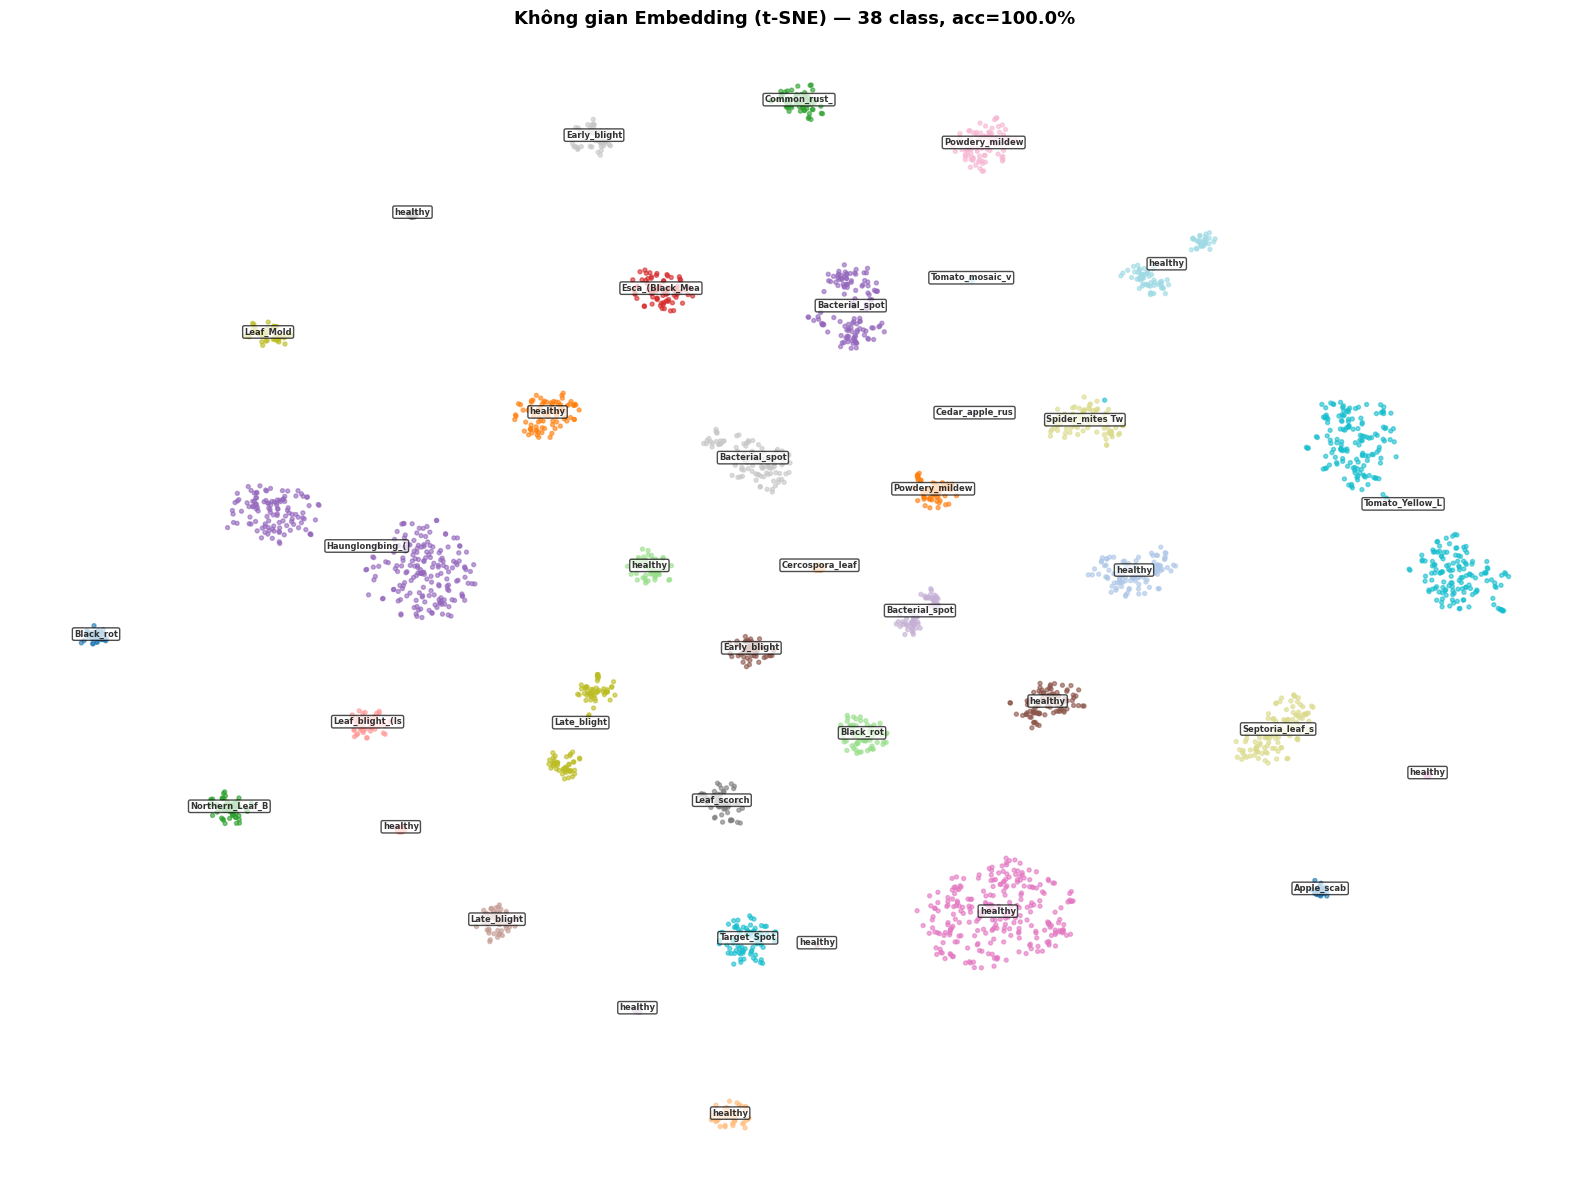

In [9]:
# ============================================================
# CELL 9 — Trực quan hóa không gian Embedding (t-SNE)
# ============================================================
from sklearn.manifold import TSNE

# Lấy mẫu cho t-SNE (toàn bộ test set có thể quá lớn)
MAX_SAMPLES = 3000
if len(test_embeddings) > MAX_SAMPLES:
    indices = np.random.choice(len(test_embeddings), MAX_SAMPLES, replace=False)
    tsne_embs   = test_embeddings[indices]
    tsne_labels = test_labels[indices]
else:
    tsne_embs   = test_embeddings
    tsne_labels = test_labels

print(f'Đang chạy t-SNE trên {len(tsne_embs)} mẫu...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
coords = tsne.fit_transform(tsne_embs)

fig, ax = plt.subplots(figsize=(16, 12))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=tsne_labels, cmap='tab20', s=8, alpha=0.6,
)

# Ghi nhãn tại tâm cụm
for i in range(NUM_CLASSES):
    mask = tsne_labels == i
    if mask.sum() > 0:
        cx, cy = coords[mask].mean(axis=0)
        short_name = CLASS_NAMES[i].split('___')[-1][:15]
        ax.annotate(short_name, (cx, cy), fontsize=6, fontweight='bold',
                    ha='center', alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title(f'Không gian Embedding (t-SNE) — {NUM_CLASSES} class, acc={test_acc*100:.1f}%',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'embedding_tsne.png'), dpi=150)
plt.show()

In [10]:
# ============================================================
# CELL 10 — Xuất mô hình cho backend
# ============================================================

final_path = MODELS_DIR / 'swin_embedding.pth'
torch.save({
    'embed_model_state' : ckpt['embed_model_state'],
    'class_names'       : CLASS_NAMES,
    'num_labels'        : NUM_CLASSES,
    'embed_dim'         : EMBED_DIM,
    'swin_config'       : ckpt['swin_config'],
    'epoch'             : ckpt['epoch'],
    'val_acc'           : ckpt['val_acc'],
}, str(final_path))

print('=' * 60)
print('TỔNG KẾT')
print('=' * 60)
print(f'Mô hình       : Swin-Small + ArcFace Embedding')
print(f'Chiều embedding: {EMBED_DIM}')
print(f'Số class       : {NUM_CLASSES}')
print(f'Epoch tốt nhất : {ckpt["epoch"]}')
print(f'Val accuracy   : {ckpt["val_acc"] * 100:.2f}%')
print(f'Test accuracy  : {test_acc * 100:.2f}% (cosine similarity)')
print(f'\nFile đã xuất:')
print(f'  Mô hình  : {final_path}')
print(f'  Prototype : {proto_path}')
print(f'\nBackend sử dụng:')
print(f'  1. Load SwinEmbedding → trích embedding')
print(f'  2. Cosine similarity với prototypes.npz → phân loại')
print(f'  3. User tải ảnh bệnh mới → tính mean embedding → thêm prototype')

TỔNG KẾT
Mô hình       : Swin-Small + ArcFace Embedding
Chiều embedding: 128
Số class       : 38
Epoch tốt nhất : 1
Val accuracy   : 99.96%
Test accuracy  : 99.98% (cosine similarity)

File đã xuất:
  Mô hình  : /content/drive/MyDrive/DATN/models/swin_embedding.pth
  Prototype : /content/drive/MyDrive/DATN/models/prototypes.npz

Backend sử dụng:
  1. Load SwinEmbedding → trích embedding
  2. Cosine similarity với prototypes.npz → phân loại
  3. User tải ảnh bệnh mới → tính mean embedding → thêm prototype
